# M1b: FM100 vs. behavioral -- testing the continuous severity spectrum

`PLANssvep_bh_fm100.md` M1: does FM100 encode a continuous severity
spectrum that correlates with the behavioral task's own severity/type
features, beyond what the categorical protan/deutan/HC/PD labels already
say? Two pre-specified tests, not a matrix of many:

1. **Severity** -- one multivariate test (CCA) between FM100's error
   magnitude (`TES`, `VKS_MajRad`, `VKS_MinRad`) and `beh/`'s M2 spread
   features (`along_var`, `perp_var`), with a permutation significance
   test.
2. **Type/axis** -- one circular correlation between FM100's confusion-
   ellipse direction (`VKS_Angle`) and `beh/`'s click-line orientation
   (`orientation_deg`, which perfectly separates protan from deutan on its
   own -- M2's headline finding).

Both deliberately avoid `ssvepBeh/`'s mistake of testing many univariate
pairs (`docs/ssvepbeh_reliability_gaps.md`). `VKS_Angle`'s own cross-
session reliability was weak (`01_fm100_reliability.ipynb`: circular
r=0.44, p=0.15) -- carried forward as a caveat on the type/axis result,
not a reason to skip it.

In [1]:
import sys
sys.path.append('../scripts')

import fm100_features

# fm100_features's own import inserts ssveps/scripts at sys.path[0] (it
# needs ssveps' reliability.py) -- ssveps/scripts has its own plotting.py
# too, so re-assert this project's scripts/ first before resolving
# "plotting", or it would silently import ssveps' version instead.
sys.path.insert(0, '../scripts')
import plotting
import severity
import type_axis

import pandas as pd

# ssveps/scripts (on sys.path from fm100_features's own import) also has a
# loader.py -- appending beh/scripts to the *end* wouldn't win the bare
# "loader"/"features" name search, since ssveps/scripts is still ahead of
# it. Move beh/scripts to the front instead, and drop any stale cache.
if '../../beh/scripts' in sys.path:
    sys.path.remove('../../beh/scripts')
sys.path.insert(0, '../../beh/scripts')
for _name in ('loader', 'features'):
    sys.modules.pop(_name, None)
import loader as beh_loader
import features as beh_features

import matplotlib.pyplot as plt

fm100_df = fm100_features.fm100_loader.load_fm100_raw()
beh_df = beh_loader.load_behavioral()

fm100_pooled = fm100_features.subject_pooled_features(fm100_df)
beh_rows = []
for s in beh_df['sub_id'].unique():
    clicks = beh_df.loc[beh_df['sub_id'] == s, ['red', 'green']]
    beh_rows.append({'sub_id': s, 'red': clicks['red'].mean(), 'green': clicks['green'].mean(), **beh_features.subject_shape_features(beh_df, s)})
beh_table = pd.DataFrame(beh_rows)

merged = fm100_pooled.merge(beh_table, on='sub_id', suffixes=('_fm100', '_beh'))
print(f"{len(merged)} subjects with both FM100 and behavioral data")
merged.groupby(['group', 'subgroup'])['sub_id'].nunique()

47 subjects with both FM100 and behavioral data


group    subgroup
CTR      NA          21
CVD      deutan       7
         protan       8
HD       NA           1
PD       NA           6
UNKNOWN  NA           4
Name: sub_id, dtype: int64

## Test 1: severity (CCA)

In [2]:
SEVERITY_FM100 = ['TES', 'VKS_MajRad', 'VKS_MinRad']
SEVERITY_BEH = ['along_var', 'perp_var']

X_all = merged[SEVERITY_FM100].to_numpy()
Y_all = merged[SEVERITY_BEH].to_numpy()
severity_result = severity.cca_test(X_all, Y_all, n_perm=5000, seed=0)
print(f"r={severity_result['r']:.3f}, p={severity_result['p_value']:.4f}, n={len(merged)}")

r=0.734, p=0.0002, n=47


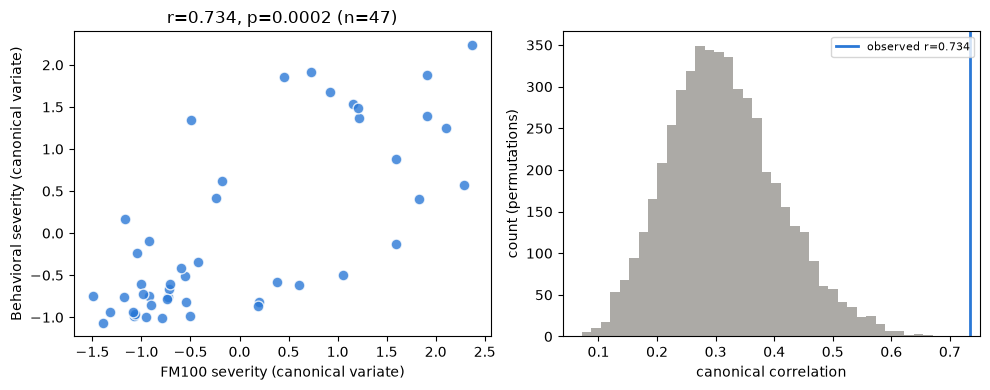

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plotting.plot_canonical_variates(severity_result, x_label='FM100 severity (canonical variate)', y_label='Behavioral severity (canonical variate)', ax=axes[0])
plotting.plot_null_distribution(severity_result, ax=axes[1])
fig.tight_layout()

**Pooled across all 47 subjects, this is strong and highly significant**
(r=0.73, p<0.001) -- far above the permutation null, which itself sits
around r=0.3-0.5 purely by chance at this n and feature count (see
`severity.py`'s module docstring for why the raw r alone would be
misleading without this null).

### But does it hold up within a single group?

A pooled correlation across the full HC-to-CVD range could just mean "sick
people click and score differently from healthy people" -- something we
already knew from the group comparisons -- rather than a genuine
continuous relationship. Testing within each group separately (a narrower,
more homogeneous severity range) is the sharper test of the actual
hypothesis.

In [4]:
categories = [
    ('all', merged),
    ('HC', merged[merged.group == 'CTR']),
    ('PD', merged[merged.group == 'PD']),
    ('CVD', merged[merged.group == 'CVD']),
    ('protan', merged[merged.subgroup == 'protan']),
    ('deutan', merged[merged.subgroup == 'deutan']),
]

rows = []
for label, sub in categories:
    if len(sub) < 3:
        rows.append({'category': label, 'n': len(sub), 'r': None, 'p_value': None})
        continue
    r = severity.cca_test(sub[SEVERITY_FM100].to_numpy(), sub[SEVERITY_BEH].to_numpy(), n_perm=2000, seed=0)
    rows.append({'category': label, 'n': len(sub), 'r': r['r'], 'p_value': r['p_value']})
severity_by_group = pd.DataFrame(rows)
severity_by_group

,category,n,r,p_value
0,all,47,0.733631,0.000500
1,HC,21,0.579860,0.228386
2,PD,6,0.995214,0.153923
3,CVD,15,0.660189,0.282859
4,protan,8,0.967150,0.128436
5,deutan,7,0.908145,0.373813


**Only the pooled result is significant.** Within HC alone (n=21), r=0.58
but p=0.23 -- not significant. CVD (n=15) and PD (n=6) show high r but
aren't significant either, and protan/deutan individually are far too
small to say anything (n=8, n=7). **Honest read: the pooled severity
result is at least partly, maybe mostly, a between-group effect** (CVD
scores worse on both FM100 and behavioral severity than HC does, which
inflates a pooled correlation without requiring a true within-group
continuum). This doesn't rule out a real continuum -- CTR's r=0.58 is not
small, just underpowered at n=21 -- but it means the severity result
should be reported as "significant when pooling across diagnostic groups,
not yet confirmed as a within-group continuum" rather than the stronger
claim.

## Test 2: type/axis (circular correlation)

In [5]:
type_result = type_axis.circular_correlation_test(merged['VKS_Angle'].to_numpy(), merged['orientation_deg'].to_numpy())
print(type_result)

{'r': 0.3745563041637358, 'p_value': 0.00913578774954786, 'n': 47}


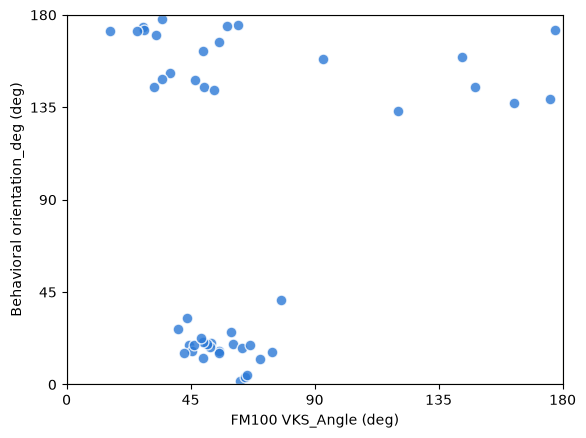

In [6]:
plotting.plot_circular_scatter(merged['VKS_Angle'].to_numpy(), merged['orientation_deg'].to_numpy(), x_label='FM100 VKS_Angle (deg)', y_label='Behavioral orientation_deg (deg)');

In [7]:
rows = []
for label, sub in categories:
    if len(sub) < 3:
        rows.append({'category': label, 'n': len(sub), 'r': None, 'p_value': None})
        continue
    t = type_axis.circular_correlation_test(sub['VKS_Angle'].to_numpy(), sub['orientation_deg'].to_numpy())
    rows.append({'category': label, 'n': len(sub), 'r': t['r'], 'p_value': t['p_value']})
type_by_group = pd.DataFrame(rows)
type_by_group

,category,n,r,p_value
0,all,47,0.374556,0.009136
1,HC,21,-0.466190,0.175428
2,PD,6,0.324326,0.505292
3,CVD,15,0.556846,0.030890
4,protan,8,0.348655,0.126043
5,deutan,7,0.114293,0.764691


**Pooled: significant** (r=0.37, p=0.009). More interesting: **it holds up
*within CVD alone*** (n=15, r=0.56, p=0.031) -- unlike the severity result,
this isn't just a between-group artifact, since CVD subjects span a real
range of confusion-ellipse directions and click-line orientations that
covary with each other even without HC in the mix. CTR alone actually
trends *negative* (r=-0.47, p=0.18, not significant) -- worth keeping an
eye on rather than a contradiction to explain away yet, given CTR's own
`VKS_Angle` is presumably closer to uniformly distributed (no dominant
confusion axis in a healthy visual system), where a circular correlation
is intrinsically noisier to estimate. protan/deutan individually are
underpowered (n=8, n=7), same limitation as everywhere else in this
project at the subtype level.

## Context table: full univariate feature matrix (not a significance claim)

Shown for completeness and to spot anything the two primary tests might
be missing -- explicitly *not* used to claim significance (that's what the
two pre-specified tests above are for).

In [8]:
import pingouin as pg

fm100_feats = ['TES', 'VKS_Angle', 'VKS_MajRad', 'VKS_MinRad']
beh_feats = ['orientation_deg', 'along_var', 'perp_var', 'red', 'green']

context_rows = []
for ff in fm100_feats:
    for bf in beh_feats:
        result = pg.corr(merged[ff], merged[bf], method='spearman')
        context_rows.append({'fm100_feature': ff, 'beh_feature': bf, 'r': result['r'].iloc[0], 'p_value': result['p_val'].iloc[0], 'n': int(result['n'].iloc[0])})
context_table = pd.DataFrame(context_rows)
context_table.sort_values('p_value').head(10)

,fm100_feature,beh_feature,r,p_value,n
1,TES,along_var,0.696605,5.387194e-08,47
11,VKS_MajRad,along_var,0.688599,8.796071e-08,47
16,VKS_MinRad,along_var,0.675648,1.882754e-07,47
15,VKS_MinRad,orientation_deg,0.570883,2.786956e-05,47
0,TES,orientation_deg,0.564456,3.586965e-05,47
10,VKS_MajRad,orientation_deg,0.550648,6.061989e-05,47
13,VKS_MajRad,red,-0.473636,7.718695e-04,47
3,TES,red,-0.464982,9.912309e-04,47
4,TES,green,0.456018,1.275706e-03,47
14,VKS_MajRad,green,0.454672,1.324188e-03,47


## Summary

- **Severity**: strong and significant *pooled* (r=0.73, p<0.001), but
  doesn't hold up within any single group at this project's n -- most
  likely partly a between-group effect. Worth re-testing once per-group
  samples grow (the same standing recommendation `ssveps/`'s M6-M10 work
  has made throughout).
- **Type/axis**: significant pooled (r=0.37, p=0.009) *and* significant
  within CVD alone (r=0.56, p=0.031, n=15) -- the stronger, more
  surprising result of the two, though `VKS_Angle`'s own moderate
  cross-session reliability (r=0.44, `01_fm100_reliability.ipynb`) means
  this is a real signal riding on a noisier measurement, not a clean one.
- Both results support the core hypothesis -- FM100 does encode information
  correlated with behavioral severity/type beyond the categorical labels --
  with the type/axis question currently the more solid of the two.